In [1]:
!pip install jax
!pip install jaxopt
!pip install joblib

     |████████████████████████████████| 2.0 MB 8.3 MB/s eta 0:00:01
     |████████████████████████████████| 71 kB 634 kB/s s eta 0:00:01
     |████████████████████████████████| 5.0 MB 85.0 MB/s eta 0:00:01
     |████████████████████████████████| 79.6 MB 95.8 MB/s eta 0:00:01
     |████████████████████████████████| 172 kB 7.9 MB/s eta 0:00:01
     |████████████████████████████████| 309 kB 8.2 MB/s eta 0:00:01


In [2]:
import glob
import logging
import os
import warnings
from time import time

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from inspect import signature
from joblib import Parallel, delayed
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from numpy.typing import NDArray
from scipy.optimize import minimize, OptimizeWarning
from scipy.stats import skew
from statsmodels.robust.norms import TukeyBiweight, RobustNorm
from statsmodels.robust import scale

In [3]:
%matplotlib inline

## Function definitions
#### Baselines

In [4]:
def single_exp(
    timestamps: np.ndarray,
    b_inf: float,
    b_slow: float = 0,
    t_slow: float = np.inf,
) -> np.ndarray:
    """Baseline with exponential decay (bleaching).

    Parameters
    ----------
    timestamps : np.ndarray
        Fiber photometry timestamps.
    b_inf : float
        Asymptotic baseline value.
    b_slow : float, optional
        Amplitude of the slow decay component. Default is 0.
    t_slow : float, optional
        Time constant of the slow decay component in seconds. Default is np.inf.

    Returns
    -------
    np.ndarray
        Baseline signal.
    """
    return b_inf * (1 + b_slow * np.exp(-timestamps / t_slow))


def double_exp(
    timestamps: np.ndarray,
    b_inf: float,
    b_slow: float = 0,
    b_fast: float = 0,
    t_slow: float = np.inf,
    t_fast: float = np.inf,
) -> np.ndarray:
    """Baseline with Biphasic exponential decay (bleaching).

    Parameters
    ----------
    timestamps : np.ndarray
        Fiber photometry timestamps.
    b_inf : float
        Asymptotic baseline value.
    b_slow : float, optional
        Amplitude of the slow decay component. Default is 0.
    b_fast : float, optional
        Amplitude of the fast decay component. Default is 0.
    t_slow : float, optional
        Time constant of the slow decay component in seconds. Default is np.inf.
    t_fast : float, optional
        Time constant of the fast decay component in seconds. Default is np.inf.

    Returns
    -------
    np.ndarray
        Baseline signal.
    """
    return b_inf * (
            1
            + b_slow * np.exp(-timestamps / t_slow)
            + b_fast * np.exp(-timestamps / t_fast)
    )


def bright(
    timestamps: np.ndarray,
    b_inf: float,
    b_slow: float = 0,
    b_fast: float = 0,
    b_rapid: float = 0,
    b_bright: float = 0,
    t_slow: float = np.inf,
    t_fast: float = np.inf,
    t_rapid: float = np.inf,
    t_bright: float = np.inf,
) -> np.ndarray:
    """Baseline with Triphasic exponential decay (bleaching) x increasing saturating exponential (brightening).

    Parameters
    ----------
    timestamps : np.ndarray
        Fiber photometry timestamps.
    b_inf : float
        Asymptotic baseline value.
    b_slow : float, optional
        Amplitude of the slow decay component. Default is 0.
    b_fast : float, optional
        Amplitude of the fast decay component. Default is 0.
    b_rapid : float, optional
        Amplitude of the rapid decay component. Default is 0.
    b_bright : float, optional
        Amplitude of the brightening component. Default is 0.
    t_slow : float, optional
        Time constant of the slow decay component in seconds. Default is np.inf.
    t_fast : float, optional
        Time constant of the fast decay component in seconds. Default is np.inf.
    t_rapid : float, optional
        Time constant of the rapid decay component in seconds. Default is np.inf.
    t_bright : float, optional
        Time constant of the brightening component in seconds. Default is np.inf.

    Returns
    -------
    np.ndarray
        Baseline signal.
    """
    return (
        b_inf
        * (
            1
            + b_slow * np.exp(-timestamps / t_slow)
            + b_fast * np.exp(-timestamps / t_fast)
            + b_rapid * np.exp(-timestamps / t_rapid)
        )
        * (1 - b_bright * np.exp(-timestamps / t_bright))
    )

#### Jacobians

In [5]:
def exp_jac(t, b_inf, b_s, tau_s):
    exp_s = np.exp(-t/tau_s)
    
    J = np.empty((t.size, 3))
    
    J[:,0] = 1 + b_s*exp_s
    J[:,1] = b_inf * exp_s
    J[:,2] = b_inf * b_s * exp_s * (t / tau_s**2)
    
    return J


def double_exp_jac(t, b_inf, b_s, b_f, tau_s, tau_f):
    exp_s = np.exp(-t/tau_s)
    exp_f = np.exp(-t/tau_f)
    
    J = np.empty((t.size, 5))
    
    J[:,0] = 1 + b_s*exp_s + b_f*exp_f
    J[:,1] = b_inf * exp_s
    J[:,2] = b_inf * exp_f
    J[:,3] = b_inf * b_s * exp_s * (t / tau_s**2)
    J[:,4] = b_inf * b_f * exp_f * (t / tau_f**2)
    
    return J


def bright_jac(
    t,
    b_inf,
    b_slow, b_fast, b_rapid,
    b_bright,
    t_slow, t_fast, t_rapid,
    t_bright,
):

    E_slow = np.exp(-t/t_slow)
    E_fast = np.exp(-t/t_fast)
    E_rapid = np.exp(-t/t_rapid)
    E_bright = np.exp(-t/t_bright)

    A = 1 + b_slow*E_slow + b_fast*E_fast + b_rapid*E_rapid
    B = 1 - b_bright*E_bright

    J = np.empty((t.size, 9))

    J[:,0] = A * B
    J[:,1] = b_inf * E_slow * B
    J[:,2] = b_inf * E_fast * B
    J[:,3] = b_inf * E_rapid * B
    J[:,4] = -b_inf * A * E_bright

    J[:,5] = b_inf * b_slow * E_slow * (t / t_slow**2) * B
    J[:,6] = b_inf * b_fast * E_fast * (t / t_fast**2) * B
    J[:,7] = b_inf * b_rapid * E_rapid * (t / t_rapid**2) * B

    J[:,8] = b_inf * A * b_bright * E_bright * (t / t_bright**2)

    return J

#### Fit

In [6]:
def tc_brightfit(
    trace: np.ndarray,
    timestamps: np.ndarray,
    rss_thresh: tuple[float, float] = (0.98, 0.997),
    M: RobustNorm = TukeyBiweight(3),
    maxiter: int = 5,
    tol: float = 1e-3,
    update_scale: bool = True,
    skewness_factor: float = 1.0,
    plot: bool = False,
) -> tuple[np.ndarray, np.ndarray]:
    """Fit trace with baseline (bleaching x brightening) using OLS or IRLS.

    More complex models that include brightening and/or a third exponential
    are only selected if they notably improve the fit by reducing the RSS.

    Parameters
    ----------
    trace : np.ndarray
        Fiber photometry signal.
    timestamps : np.ndarray
        Fiber photometry timestamps.
    rss_thresh : float or tuple of float or str, optional
        Factor(s) used for model selection. Default is (0.98, 0.997).
        If a tuple, then the order is (brightening, 3rd exponential).
        A more complex model (with 2 additional parameters)
        is accepted if the RSS decreases by at least this factor.
        Automatically calculated if "AIC" or "BIC".
    M : statsmodels.robust.norms.RobustNorm or None, optional
        The robust criterion function for downweighting outliers.
        Default is TukeyBiweight(3).
    maxiter : int, optional
        The maximum number of IRLS iterations to try. Default is 5.
        Has to be >0 for robust regression, 0 uses only OLS.
    tol : float, optional
        The convergence tolerance of the estimate. Default is 1e-3.
    update_scale : bool, optional
        If False, scale estimate for weights is held constant over iteration.
        If True, it is updated for each fit. Default is True.
    skewness_factor : float, optional
        Scaling factor to correct for bias by performing asymmetric
        robust regression based on skewness of the residuals. Default is 1.0.
    plot : bool, optional
        Whether to plot the fits. Default is False.

    Returns
    -------
    tuple
        - baseline : np.ndarray
            The fitted baseline.
        - params : np.ndarray
            Optimal values for the parameters of the preprocessing.
    """

    # constants for fancy logging
    CEND = "\33[0m"
    CBOLD = "\33[1m"
    CRED = "\33[31m"
    CGREEN = "\33[32m"

    T = len(trace)
    Tds = T // 10
    if rss_thresh == "BIC":
        rss_thresh = [Tds ** (-2 / Tds)] * 2
    elif rss_thresh == "AIC":
        rss_thresh = [np.exp(-4 / Tds)] * 2

    def optimize(trace, x0, ds=1, maxiter=20000, weights=1, plot=plot):
        """if item in x0 is set to np.nan it is not optimized but
        set to its default, i.e. this exponential term is excluded
        """
        trace_ds = trace[: T // ds * ds].reshape(-1, ds).mean(1)
        optimize_param = ~np.isnan(x0)
        params = np.array([0] * 5 + [np.inf] * 4)  # default params if not optimized

        def objective(params_to_optimize):
            params[optimize_param] = params_to_optimize
            return np.sum(
                weights
                * (
                    trace_ds
                    - bright(timestamps[ds // 2 :: ds][: len(trace_ds)], *params)
                )
                ** 2
            )

        bounds = np.array(
            [(0, np.inf)] * 5 + [(300, np.inf), (1, 1200), (1, 180), (60, np.inf)]
        )
        res = minimize(
            objective,
            np.array(x0)[optimize_param],
            bounds=bounds[optimize_param],
            method="Nelder-Mead",
            options={"maxiter": maxiter},
        )
        params[optimize_param] = res.x
        logging.info(
            f"Cost: {res.fun:.3f}  "
            f"Success: {CGREEN if res.success else CRED} {res.success} {CEND}  "
            f"{res.message}"
        )
        if plot:
            plot_fit(params, trace, timestamps)
        return params, res.fun, res.success, res.message

    x0 = np.array(
        [trace[-1000:].mean(), 0.35, 0.2, np.nan, np.nan, 3600, 240, np.nan, np.nan]
    )
    logging.info(f"{CBOLD}Fit of 10x decimated trace with double-exp{CEND}")
    x2, cost2, success2, _ = optimize(trace, x0, 10)
    if x2[6] > x2[5]:  # swap t_slow and t_fast if optimization returns t_fast > t_slow
        x2[[1, 2, 5, 6]] = x2[[2, 1, 6, 5]]

    x0[~np.isnan(x0)] = x2[~np.isnan(x0)]
    x0[[4, 8]] = 0.1, 2000
    logging.info(f"{CBOLD}Fit of 10x decimated trace with brightening{CEND}")
    xB, costB, successB, _ = optimize(trace, x0, 10, 3000)

    cost_ratio = costB / cost2
    include_bright = cost_ratio < rss_thresh[0]
    logging.info(
        f"Cost reduction by including brightening is {(cost_ratio-1)*100:.3f}%, "
        f"thus {CBOLD}{'including' if include_bright else 'skipping'}{CEND} brightening term."
        + ("\n" if plot else "")
    )
    if include_bright:
        x0[~np.isnan(x0)] = xB[~np.isnan(x0)]
    else:
        x0[[4, 8]] = np.nan
    x0[[3, 7]] = 0.1, 50
    logging.info(f"{CBOLD}Fit of 10x decimated trace with triple-exp{CEND}")
    x3, cost3, success3, _ = optimize(trace, x0, 10, 3000)
    # swap as needed to ensure t_slow > t_fast > t_rapid
    order = np.argsort(x3[5:8])[::-1]
    x3[5:8] = x3[5 + order]
    x3[1:4] = x3[1 + order]

    cost_ratio = cost3 / (costB if include_bright else cost2)
    include_3rd = cost_ratio < rss_thresh[1]
    logging.info(
        f"Cost reduction by including 3rd exponential is {(cost_ratio-1)*100:.3f}%, "
        f"thus {CBOLD}{'including' if include_3rd else 'skipping'}{CEND} 3rd exponential term."
        + ("\n" if plot else "")
    )
    if include_3rd:
        x0[~np.isnan(x0)] = x3[~np.isnan(x0)]
    else:
        x0[[3, 7]] = np.nan
    params = np.array([0] * 5 + [np.inf] * 4)
    params[~np.isnan(x0)] = x0[~np.isnan(x0)]
    logging.info(
        f"Cost on original trace with params obtained on decimated trace is "
        f"{np.sum((trace - bright(timestamps, *params)) ** 2):.3f}"
    )
    logging.info(
        f"{CBOLD}Fit of original trace with {'triple-exp' if include_3rd else 'double-exp'} "
        f"and {'' if include_bright else 'no '}brightening{CEND}"
    )
    x, cost, success, msg = optimize(trace, x0)

    # robust fit down-weighting outliers using IRLS
    # see https://github.com/statsmodels/statsmodels/blob/main/statsmodels/robust/robust_linear_model.py#L196
    if maxiter > 0 and M is not None and cost > 0:
        f0 = bright(timestamps, *x)
        resid = trace - f0
        scl = scale.mad(resid if skewness_factor == 0 else resid[resid < 0], center=0)
        deviance = M(resid / scl).sum()
        iteration = 0
        converged = False
        while not converged:
            iteration += 1
            if scl == 0.0:
                import warnings

                warnings.warn(
                    "Estimated scale is 0.0 indicating that the most"
                    " last iteration produced a perfect fit of the "
                    "weighted data."
                )
                break
            if skewness_factor != 0:
                avg_skew = np.mean(
                    [skew((resid)[t0 : t0 + 1200]) for t0 in range(0, len(resid), 1200)]
                )
                resid[resid > 0] *= np.exp(skewness_factor * avg_skew)
            weights = M.weights(resid / scl)
            x[np.isnan(x0)] = np.nan  # set params of excluded terms to nan
            x, cost, success, msg = optimize(trace, x, weights=weights, plot=False)
            f0 = bright(timestamps, *x)
            resid = trace - f0
            if update_scale is True:
                scl = scale.mad(
                    resid if skewness_factor == 0 else resid[resid < 0], center=0
                )
            dev_pre = deviance
            deviance = M(resid / scl).sum()
            converged = iteration >= maxiter or np.abs(deviance / dev_pre - 1) < tol
        logging.info(
            f"{CBOLD}IRLS fit {iteration}/{maxiter} of original trace with "
            f"{'triple-exp' if include_3rd else 'double-exp'} "
            f"and {'' if include_bright else 'no '}brightening{CEND}"
        )
        logging.info(
            f"Cost: {cost:.3f}  Success: {CGREEN if success else CRED} {success} {CEND} {msg}"
        )
        if plot:
            plot_fit(x, trace, timestamps)

    return bright(timestamps, *x), x

In [7]:
def fit_baseline_trend(
    trace: np.ndarray,
    timestamps: np.ndarray,
    model: callable,
    init_params: np.ndarray,
    bounds=None,
    jac=None,
    M=None,
    optimizer="L-BFGS-B",
    maxiter=5,
    tol=1e-3,
    scale_estimator="mad",
    optimizer_options=None,
):
    """
    General nonlinear model fitting.

    Parameters
    ----------
    trace : array
        Observed signal
    timestamps : array
        Time vector (passed to model)
    model : callable
        model(timestamps, *params) -> model prediction
    init_params : array
        Initial parameter vector
    bounds : array
        Parameter bounds
    jac : callable
        Jacobian  jac(timestamps, *params) -> array_like, shape (n_samples, n_params)
    M : None or object with .rho(u)
        If None -> OLS
        If provided -> IRLS with M-estimator
    optimizer : str
        Method for scipy.optimize.minimize
    maxiter : int
        IRLS iterations (ignored if M=None)
    tol : float
        Convergence tolerance
    scale_estimator : "mad" or "std"
        Robust scale for IRLS
    optimizer_options : dict
        Passed to scipy.optimize.minimize

    Returns
    -------
    fitted_trace : array
    params : array
    """

    if optimizer_options is None:
        optimizer_options = {"maxiter": 20000}

    x = np.asarray(init_params).copy()

    # ----------------------------
    # OLS case
    # ----------------------------
    if M is None:

        def objective(p):
            resid = trace - model(timestamps, *p)
            loss = np.sum(resid ** 2)
            if jac is None:
                return loss
            J = jac(timestamps, *p)
            grad = -2 * J.T @ resid
            return loss, grad

        res = minimize(
            objective,
            x,
            bounds=bounds,
            method=optimizer,
            jac=(jac is not None),
            options=optimizer_options,
        )

        return model(timestamps, *res.x), res.x

    # ----------------------------
    # Robust IRLS case
    # ----------------------------
    for iteration in range(maxiter):

        resid = trace - model(timestamps, *x)

        if scale_estimator == "mad":
            sigma = scale.mad(resid, center=0)
            if sigma == 0:
                sigma = np.std(resid)
        else:
            sigma = np.std(resid)

        def objective(p):
            resid = trace - model(timestamps, *p)
            u = resid / sigma
            loss = np.sum(M.rho(u))
            if jac is None:
                return loss
            J = jac(timestamps, *p)
            psi = M.psi(u)
            grad = -(J.T @ psi) / sigma
            return loss, grad

        res = minimize(
            objective,
            x,
            bounds=bounds,
            method=optimizer,
            jac=(jac is not None),
            options=optimizer_options,
        )

        if np.linalg.norm(res.x - x) / (np.linalg.norm(x) + 1e-12) < tol:
            x = res.x
            break
        x = res.x

    return model(timestamps, *x), x

#### load data 

In [8]:
def get_valid_corrected_f(path):
    dr = path.split("/")[-1]
    data = []
    with h5py.File(f"{path}/{dr}_data.h5") as f:
        for k in f['planes'].keys():
            data.append(f[f'planes/{k}/corrected_f'][f[f'planes/{k}/valid_roi_inds'][:]])
    return data

## Data 

In [9]:
dirs = glob.glob("/data/test-dataset-for-dff_multiplane-ophys_02/*/*")
dirs

['/data/test-dataset-for-dff_multiplane-ophys_02/lamf_slc32a1_oi1/804670',
 '/data/test-dataset-for-dff_multiplane-ophys_02/lamf_slc32a1_oi1/775682',
 '/data/test-dataset-for-dff_multiplane-ophys_02/lamf_slc32a1_oi1/782149',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi4/753562',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi4/729088',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi4/758265',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi4/753561',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi4/724567',
 '/data/test-dataset-for-dff_multiplane-ophys_02/snap25_oi4_dox/755212',
 '/data/test-dataset-for-dff_multiplane-ophys_02/snap25_oi4_dox/759075',
 '/data/test-dataset-for-dff_multiplane-ophys_02/snap25_oi4_dox/726433',
 '/data/test-dataset-for-dff_multiplane-ophys_02/snap25_oi4_dox/747443',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi1/757436',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi1/69

In [10]:
traces = get_valid_corrected_f(dirs[0])

In [11]:
[t.shape for t in traces]

[(56, 48374),
 (46, 48374),
 (73, 48374),
 (73, 48374),
 (62, 48374),
 (56, 48374),
 (41, 48374),
 (49, 48374),
 (59, 48403),
 (46, 48403),
 (71, 48403),
 (75, 48403),
 (65, 48403),
 (57, 48403),
 (39, 48403),
 (53, 48403),
 (57, 48427),
 (48, 48427),
 (67, 48427),
 (73, 48427),
 (65, 48427),
 (61, 48427),
 (41, 48427),
 (48, 48427),
 (55, 48390),
 (46, 48390),
 (65, 48390),
 (76, 48390),
 (63, 48390),
 (56, 48390),
 (40, 48390),
 (48, 48390),
 (60, 48373),
 (42, 48373),
 (65, 48373),
 (76, 48373),
 (66, 48373),
 (58, 48373),
 (40, 48373),
 (52, 48373),
 (58, 48366),
 (44, 48366),
 (66, 48366),
 (75, 48366),
 (61, 48366),
 (54, 48366),
 (42, 48366),
 (51, 48366)]

In [12]:
trace = traces[0][0]

In [13]:
frame_rate = 10.63  # looked up manually from session.json of multiplane-ophys_804670_2025-09-24_09-30-56_processed_2025-10-10_22-28-44
timestamps = np.arange(len(trace)) / frame_rate

## unbounded OLS 

In [14]:
for model, jac, start_params in ((single_exp, exp_jac, [trace[-1000:].mean(), 0.35, 3600]),
                                 (double_exp, double_exp_jac, [trace[-1000:].mean(), 0.35, 0.2, 3600, 240])):
    print("\n" + model.__name__)
    for optimizer in ("Nelder-Mead", "BFGS", "L-BFGS-B", "CG", "Newton-CG", "TNC", "SLSQP", "trust-constr"):
        tic = -time()
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            warnings.simplefilter("ignore", category=OptimizeWarning)
            F0, popt = fit_baseline_trend(trace, timestamps, model, start_params,
                                          jac=None if optimizer=="Nelder-Mead" else jac,
                                          optimizer=optimizer)
        tic += time()
        with np.printoptions(precision=2, suppress=False, linewidth=120):
            print(f"{optimizer:13}  Time={tic:7.4f}s  Loss={((F0-trace)**2).mean():.2f}", popt)


single_exp
Nelder-Mead    Time= 0.1297s  Loss=73754.76 [ 1.26e+03 -2.65e-01  4.36e+03]
BFGS           Time= 0.0585s  Loss=73754.76 [ 1.26e+03 -2.65e-01  4.36e+03]
L-BFGS-B       Time= 0.0391s  Loss=73763.92 [ 1.22e+03 -2.47e-01  3.60e+03]
CG             Time= 0.9634s  Loss=73754.76 [ 1.26e+03 -2.65e-01  4.36e+03]
Newton-CG      Time= 0.3640s  Loss=73770.72 [ 1.21e+03 -2.39e-01  3.60e+03]
TNC            Time= 0.1186s  Loss=73754.76 [ 1.26e+03 -2.65e-01  4.36e+03]
SLSQP          Time= 0.4418s  Loss=77562.81 [ 1.05e+03 -6.73e-01  3.68e-03]
trust-constr   Time= 0.2228s  Loss=73754.76 [ 1.26e+03 -2.65e-01  4.36e+03]

double_exp
Nelder-Mead    Time=15.1977s  Loss=61277.80 [ 1135.14 -1675.46  1675.86   456.28   455.96]
BFGS           Time= 4.8442s  Loss=61277.80 [1135.14 -473.51  473.92  456.68  455.56]
L-BFGS-B       Time= 0.0891s  Loss=65784.35 [ 1.34e+03 -4.18e-01  6.11e-01  3.59e+03  1.58e+02]
CG             Time=48.9297s  Loss=61277.95 [1135.15  -69.52   69.92  459.93  452.35]
Newton-CG

In [15]:
for model, jac, start_params in ((single_exp, exp_jac, [trace[-1000:].mean(), 0.35, 3600]),
                                 (double_exp, double_exp_jac, [trace[-1000:].mean(), 0.35, 0.2, 3600, 240]),
                                 (bright, bright_jac, [trace[-1000:].mean(), 0.35, 0.2, 0.1, 0.1, 3600, 240, 50, 2000])):
    print("\n" + model.__name__)
    for method in ("BFGS_noJac", "BFGS", "L-BFGS-B_noJac", "L-BFGS-B"):
        optimizer = method[:-6] if method[-5:]=="noJac" else method
        tic = -time()
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            warnings.simplefilter("ignore", category=OptimizeWarning)
            F0, popt = fit_baseline_trend(trace, timestamps, model, start_params, jac=None if method[-5:]=="noJac" else jac, optimizer=optimizer,
                                          optimizer_options=dict(maxiter=20000, ftol=1e-12, gtol=1e-10))
        tic += time()
        with np.printoptions(precision=2, suppress=False, linewidth=120):
            print(f"{method:14}  Time={tic:7.4f}s  Loss={((F0-trace)**2).mean():.2f}", popt)


single_exp
BFGS_noJac      Time= 0.0920s  Loss=73754.76 [ 1.26e+03 -2.65e-01  4.36e+03]
BFGS            Time= 0.0297s  Loss=73754.76 [ 1.26e+03 -2.65e-01  4.36e+03]
L-BFGS-B_noJac  Time= 0.0373s  Loss=73763.92 [ 1.22e+03 -2.47e-01  3.60e+03]
L-BFGS-B        Time= 0.0196s  Loss=73763.92 [ 1.22e+03 -2.47e-01  3.60e+03]

double_exp
BFGS_noJac      Time= 1.8709s  Loss=61277.86 [1135.14 -108.48  108.89  458.55  453.69]
BFGS            Time= 4.5753s  Loss=61277.80 [1135.14 -473.51  473.92  456.68  455.56]
L-BFGS-B_noJac  Time= 1.8952s  Loss=61277.88 [1135.15  -92.11   92.51  459.01  453.29]
L-BFGS-B        Time= 9.1015s  Loss=61277.80 [ 1135.14 -1012.89  1013.3    456.38   455.85]

bright
BFGS_noJac      Time= 2.2371s  Loss=58988.11 [ 3.21e+02  3.94e+01 -3.41e+02  6.07e+02  9.86e-01  3.15e+03  2.33e+02  2.04e+02  1.27e+04]
BFGS            Time= 0.6513s  Loss=66064.57 [1.14e+03 2.09e-01 6.75e-01 2.07e+00 5.79e-01 3.60e+03 2.38e+02 1.11e+02 2.03e+03]
L-BFGS-B_noJac  Time= 3.4142s  Loss=59444.

## bounded OLS 

In [16]:
for model, jac, start_params, bounds in (
    (single_exp, exp_jac, [trace[-1000:].mean(), 0.35, 3600], [(0, np.inf)] * 2 + [(300, np.inf)]),
    (double_exp, double_exp_jac, [trace[-1000:].mean(), 0.35, 0.2, 3600, 240], [(0, np.inf)] * 3 + [(300, np.inf), (1, 1200)]),
    (bright, bright_jac, [trace[-1000:].mean(), 0.35, 0.2, 0.1, 0.1, 3600, 240, 50, 2000], [(0, np.inf)] * 5 + [(300, np.inf), (1, 1200), (1, 180), (60, np.inf)])
):
    print("\n" + model.__name__)
    for method in ("Nelder-Mead", "L-BFGS-B_noJac", "L-BFGS-B"):
        optimizer = method[:-6] if method[-5:]=="noJac" else method
        tic = -time()
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            warnings.simplefilter("ignore", category=OptimizeWarning)
            F0, popt = fit_baseline_trend(trace, timestamps, model, start_params, bounds=bounds,
                                          jac=jac if method=="L-BFGS-B" else None,
                                          optimizer=optimizer,
                                          optimizer_options=dict(maxiter=20000, ftol=1e-12, gtol=1e-10) if optimizer=="L-BFGS-B" else None)
        tic += time()
        with np.printoptions(precision=2, suppress=False, linewidth=120):
            print(f"{method:14}  Time={tic:7.4f}s  Loss={((F0-trace)**2).mean():.2f}", popt)


single_exp
Nelder-Mead     Time= 0.0757s  Loss=77573.12 [ 1049.25     0.   11951.34]
L-BFGS-B_noJac  Time= 0.0200s  Loss=77573.12 [1049.25    0.   3485.95]
L-BFGS-B        Time= 0.0287s  Loss=77573.12 [1049.25    0.   3485.95]

double_exp
Nelder-Mead     Time= 0.4175s  Loss=75145.74 [1.04e+03 0.00e+00 4.69e-01 3.00e+02 9.70e+01]
L-BFGS-B_noJac  Time= 0.1229s  Loss=75145.74 [1.04e+03 0.00e+00 4.69e-01 3.37e+03 9.70e+01]
L-BFGS-B        Time= 0.0783s  Loss=75145.74 [1.04e+03 0.00e+00 4.69e-01 3.37e+03 9.70e+01]

bright
Nelder-Mead     Time=23.1599s  Loss=58919.91 [7.31e+02 2.40e+03 2.04e+04 1.82e+02 1.00e+00 2.96e+03 1.58e+02 1.00e+00 1.72e+06]
L-BFGS-B_noJac  Time= 1.2021s  Loss=59358.64 [6.89e+02 2.51e+00 3.29e+01 3.17e-02 9.50e-01 3.58e+03 1.47e+02 1.66e+02 1.97e+03]
L-BFGS-B        Time= 1.0954s  Loss=59340.14 [6.76e+02 2.66e+00 3.43e+01 3.66e-04 9.51e-01 3.57e+03 1.47e+02 6.28e+01 2.03e+03]


## bounded robust regression (Tukey) 

In [17]:
for model, jac, start_params, bounds in (
    (single_exp, exp_jac, [trace[-1000:].mean(), 0.35, 3600], [(0, np.inf)] * 2 + [(300, np.inf)]),
    (double_exp, double_exp_jac, [trace[-1000:].mean(), 0.35, 0.2, 3600, 240], [(0, np.inf)] * 3 + [(300, np.inf), (1, 1200)]),
    (bright, bright_jac, [trace[-1000:].mean(), 0.35, 0.2, 0.1, 0.1, 3600, 240, 50, 2000], [(0, np.inf)] * 5 + [(300, np.inf), (1, 1200), (1, 180), (60, np.inf)])
):
    print("\n" + model.__name__)
    for method in ("Nelder-Mead", "L-BFGS-B_noJac", "L-BFGS-B"):
        optimizer = method[:-6] if method[-5:]=="noJac" else method
        tic = -time()
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            warnings.simplefilter("ignore", category=OptimizeWarning)
            F0, popt = fit_baseline_trend(trace, timestamps, model, start_params, bounds=bounds,
                                          M=TukeyBiweight(3),
                                          jac=jac if method=="L-BFGS-B" else None,
                                          optimizer=optimizer,
                                          optimizer_options=dict(maxiter=20000, ftol=1e-12, gtol=1e-10) if optimizer=="L-BFGS-B" else None)
        tic += time()
        with np.printoptions(precision=2, suppress=False, linewidth=120):
            print(f"{method:14}  Time={tic:7.4f}s  Loss={((F0-trace)**2).mean():.2f}", popt)


single_exp
Nelder-Mead     Time= 0.6881s  Loss=77912.90 [ 1030.81     0.   18031.2 ]
L-BFGS-B_noJac  Time= 0.0801s  Loss=77912.50 [1030.83    0.   3599.02]
L-BFGS-B        Time= 0.0366s  Loss=77912.50 [1030.83    0.   3599.02]

double_exp
Nelder-Mead     Time= 1.7923s  Loss=75562.47 [1.02e+03 4.32e-16 5.00e-01 1.91e+04 1.03e+02]
L-BFGS-B_noJac  Time= 0.6393s  Loss=75562.15 [1.02e+03 0.00e+00 5.00e-01 3.60e+03 1.03e+02]
L-BFGS-B        Time= 0.2327s  Loss=75562.14 [1.02e+03 0.00e+00 5.00e-01 3.60e+03 1.03e+02]

bright
Nelder-Mead     Time=44.2764s  Loss=59415.31 [3.72e+02 2.93e+04 1.52e+04 2.59e+05 1.00e+00 2.96e+03 2.65e+02 1.47e+02 1.09e+07]
L-BFGS-B_noJac  Time= 4.4933s  Loss=59299.39 [6.06e+02 3.17e+00 7.17e+01 2.93e+02 9.94e-01 3.57e+03 1.31e+02 1.68e+01 1.98e+03]
L-BFGS-B        Time= 1.8609s  Loss=59846.24 [6.68e+02 2.63e+00 3.14e+01 2.38e+00 9.49e-01 3.58e+03 1.46e+02 1.50e+02 2.05e+03]


In [31]:
for model, jac, start_params, bounds in (
    # (single_exp, exp_jac, [trace[-1000:].mean(), 0.35, 3600], [(0, np.inf)] * 2 + [(300, np.inf)]),
    # (double_exp, double_exp_jac, [trace[-1000:].mean(), 0.35, 0.2, 3600, 240], [(0, np.inf)] * 3 + [(300, np.inf), (1, 1200)]),
    (bright, bright_jac, [trace[-1000:].mean(), 0.35, 0.2, 0.1, 0.1, 3600, 240, 50, 2000], [(0, np.inf)] * 5 + [(300, np.inf), (1, 1200), (1, 180), (60, np.inf)]),
):
    print("\n" + model.__name__)
    for method in ("L-BFGS-B",):
        optimizer = method[:-6] if method[-5:]=="noJac" else method
        tic = -time()
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            warnings.simplefilter("ignore", category=OptimizeWarning)
            F0, popt = fit_baseline_trend(trace, timestamps, model, start_params, bounds=bounds,
                                          M=TukeyBiweight(3),
                                          jac=jac if method=="L-BFGS-B" else None,
                                          optimizer=optimizer,
                                          optimizer_options=dict(maxiter=20000, ftol=1e-12, gtol=1e-10) if optimizer=="L-BFGS-B" else None)
        tic += time()
        with np.printoptions(precision=2, suppress=False, linewidth=120):
            print(f"{method:14}  Time={tic:7.4f}s  Loss={((F0-trace)**2).mean():.2f}", popt)


bright
L-BFGS-B        Time= 1.3298s  Loss=59846.24 [6.68e+02 2.63e+00 3.14e+01 2.38e+00 9.49e-01 3.58e+03 1.46e+02 1.50e+02 2.05e+03]


In [35]:
TukeyBiweight(3).rho??

Object `rho` not found.


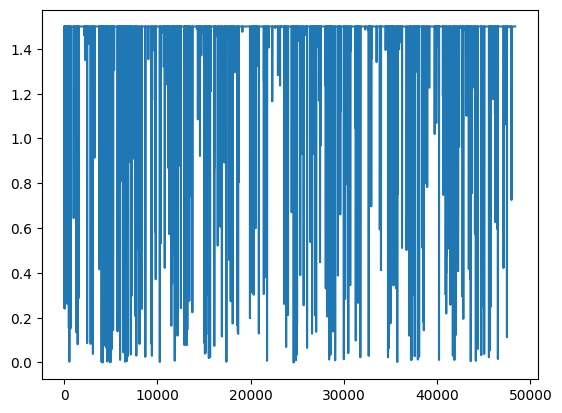

In [38]:
plt.plot(TukeyBiweight(3).rho(r:=trace-F0))

In [14]:
tic = -time()
F0, popt = tc_brightfit(trace, np.arange(len(trace)) / frame_rate, M=TukeyBiweight(3), skewness_factor=0)
tic += time()
with np.printoptions(precision=2, suppress=False, linewidth=120):
    print(f"{'bright':14}  Time={tic:7.4f}s  Loss={((F0-trace)**2).mean():.2f}", popt)

bright          Time= 3.3996s  Loss=60768.64 [1.11e+03 2.62e-13 1.55e+01 7.63e+01 9.89e-01 1.24e+04 1.24e+02 1.46e+01 6.88e+02]


In [27]:
for model, jac, start_params, bounds in (
    (single_exp, exp_jac, [trace[-1000:].mean(), 0.35, 3600], [(0, np.inf)] * 2 + [(300, np.inf)]),
    (double_exp, double_exp_jac, [trace[-1000:].mean(), 0.35, 0.2, 3600, 240], [(0, np.inf)] * 3 + [(300, np.inf), (1, 1200)]),
    (bright, bright_jac, [trace[-1000:].mean(), 0.35, 0.2, 0.1, 0.1, 3600, 240, 50, 2000], [(0, np.inf)] * 5 + [(300, np.inf), (1, 1200), (1, 180), (60, np.inf)])
):
    print("\n" + model.__name__)
    n_jobs = min(len(traces[0]), int(os.getenv("CO_CPUS", -1)))
    for method in ("Nelder-Mead", "L-BFGS-B_noJac", "L-BFGS-B"):
        optimizer = method[:-6] if method[-5:]=="noJac" else method
        tic = -time()
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            warnings.simplefilter("ignore", category=OptimizeWarning)
            res = Parallel(n_jobs=n_jobs)(
                delayed(fit_baseline_trend)(
                    t, timestamps, model, start_params, bounds=bounds,
                    M=TukeyBiweight(3),
                    jac=jac if method=="L-BFGS-B" else None,
                    optimizer=optimizer,
                    optimizer_options=dict(maxiter=20000, ftol=1e-12, gtol=1e-10) if optimizer=="L-BFGS-B" else None)
                for t in traces[0][:8]
            )
        tic += time()
        with np.printoptions(precision=5, suppress=False, linewidth=120):
            print(f"{method:14}  Time={tic:8.4f}s  Norm.Loss={np.mean([np.mean((r[0] - t)**2 / t.var()) for r, t in zip(res, traces[0][:8])]):.2f}")


single_exp
Nelder-Mead     Time=116.8970s  Norm.Loss=0.95
L-BFGS-B_noJac  Time=  4.4391s  Norm.Loss=0.95
L-BFGS-B        Time= 11.3521s  Norm.Loss=0.95

double_exp
Nelder-Mead     Time=149.3618s  Norm.Loss=0.94
L-BFGS-B_noJac  Time=  9.6126s  Norm.Loss=0.94
L-BFGS-B        Time= 25.9694s  Norm.Loss=0.94

bright
Nelder-Mead     Time=183.5167s  Norm.Loss=0.71
L-BFGS-B_noJac  Time= 24.9473s  Norm.Loss=0.68
L-BFGS-B        Time= 10.2978s  Norm.Loss=0.74


In [28]:
n_jobs = min(len(traces[0]), int(os.getenv("CO_CPUS", -1)))
tic = -time()
res = Parallel(n_jobs=n_jobs)(
    delayed(tc_brightfit)(t, timestamps, M=TukeyBiweight(3), skewness_factor=0)
    for t in traces[0][:8]
)
tic += time()
with np.printoptions(precision=5, suppress=False, linewidth=120):
    print(f"{'bright':14}  Time={tic:7.4f}s  Norm.Loss={np.mean([np.mean((r[0] - t)**2 / t.var()) for r, t in zip(res, traces[0][:8])]):.2f}")

bright          Time=586.9927s  Norm.Loss=0.70


#### define model and jac together to share intermediate results 

In [14]:
def bright_model_with_jac(t, b_inf, b_slow=0, b_fast=0, b_rapid=0, b_bright=0,
                          t_slow=np.inf, t_fast=np.inf, t_rapid=np.inf, t_bright=np.inf,
                          return_jac=False):
    """Bright baseline, optionally return Jacobian."""
    E_slow = np.exp(-t/t_slow)
    E_fast = np.exp(-t/t_fast)
    E_rapid = np.exp(-t/t_rapid)
    E_bright = np.exp(-t/t_bright)

    A = 1 + b_slow*E_slow + b_fast*E_fast + b_rapid*E_rapid
    B = 1 - b_bright*E_bright
    y = b_inf * A * B

    if not return_jac:
        return y

    J = np.empty((t.size, 9))
    J[:,0] = A * B
    J[:,1] = b_inf * E_slow * B
    J[:,2] = b_inf * E_fast * B
    J[:,3] = b_inf * E_rapid * B
    J[:,4] = -b_inf * A * E_bright
    J[:,5] = b_inf * b_slow * E_slow * (t / t_slow**2) * B
    J[:,6] = b_inf * b_fast * E_fast * (t / t_fast**2) * B
    J[:,7] = b_inf * b_rapid * E_rapid * (t / t_rapid**2) * B
    J[:,8] = b_inf * A * b_bright * E_bright * (t / t_bright**2)
    return y, J

In [15]:
import inspect

def fit_baseline_trend2(
    trace: np.ndarray,
    timestamps: np.ndarray,
    model: callable,
    init_params: np.ndarray,
    bounds=None,
    M=None,
    optimizer="L-BFGS-B",
    maxiter=5,
    tol=1e-3,
    scale_estimator="mad",
    optimizer_options=None,
):
    """
    Fit a nonlinear baseline to a single trace.
    Supports OLS (M=None) or IRLS (M=M-estimator).
    Model can optionally return a Jacobian as `model(..., return_jac=True)`.
    """

    if optimizer_options is None:
        optimizer_options = {"maxiter": 20000}

    x = np.asarray(init_params).copy()

    # ----------------------------
    # check if model supports return_jac argument
    sig = inspect.signature(model)
    has_return_jac = "return_jac" in sig.parameters

    # ----------------------------
    # OLS case
    # ----------------------------
    if M is None:

        def objective(p):
            if has_return_jac:
                y_pred, J = model(timestamps, *p, return_jac=True)
                resid = trace - y_pred
                grad = -2 * J.T @ resid
                return np.sum(resid**2), grad
            else:
                resid = trace - model(timestamps, *p)
                return np.sum(resid**2)

        res = minimize(
            objective,
            x,
            bounds=bounds,
            method=optimizer,
            jac=has_return_jac,
            options=optimizer_options,
        )
        return model(timestamps, *res.x), res.x

    # ----------------------------
    # IRLS case
    # ----------------------------
    for iteration in range(maxiter):

        resid = trace - model(timestamps, *x)

        if scale_estimator == "mad":
            sigma = scale.mad(resid, center=0)
            if sigma == 0:
                sigma = np.std(resid)
        else:
            sigma = np.std(resid)

        def objective(p):
            resid = trace - model(timestamps, *p)
            u = resid / sigma
            loss = np.sum(M.rho(u))
            if has_return_jac:
                _, J = model(timestamps, *p, return_jac=True)
                psi = M.psi(u)
                grad = -(J.T @ psi) / sigma
                return loss, grad
            else:
                return loss

        res = minimize(
            objective,
            x,
            bounds=bounds,
            method=optimizer,
            jac=has_return_jac,
            options=optimizer_options,
        )

        # convergence
        if np.linalg.norm(res.x - x) / (np.linalg.norm(x) + 1e-12) < tol:
            x = res.x
            break
        x = res.x

    return model(timestamps, *x), x

#### use jax autograd

In [16]:
import jax
import jax.numpy as jnp
from jax import jit, grad
from scipy.optimize import minimize


class TukeyBiweight_jax:
    """Tukey biweight M-estimator"""
    def __init__(self, c=4.685):
        self.c = c

    def rho(self, u):
        c = self.c
        abs_u = jnp.abs(u)
        mask = abs_u <= c
        return jnp.where(mask, (c**2/6) * (1 - (1 - (u/c)**2)**3), c**2/6)

    def psi(self, u):
        c = self.c
        mask = jnp.abs(u) <= c
        return jnp.where(mask, u * (1 - (u/c)**2)**2, 0.0)


def fit_baseline_jax(
    trace,
    timestamps,
    model,
    init_params,
    bounds=None,
    M=None,
    maxiter=5,
    tol=1e-3,
):
    """
    JAX-based nonlinear baseline fitting.

    Parameters
    ----------
    trace : array
    timestamps : array
    model : callable
        model(params, timestamps)
    init_params : array
    bounds : sequence of (min,max)
    M : None or object with rho(u), psi(u)
    maxiter : IRLS iterations
    tol : convergence tolerance
    """

    t = jnp.array(timestamps)
    y = jnp.array(trace)
    x = jnp.array(init_params)

    # -------------------------
    # OLS loss
    # -------------------------

    def loss(params):
        resid = y - model(params, t)
        return jnp.sum(resid ** 2)

    grad_loss = jax.grad(loss)

    loss_jit = jax.jit(loss)
    grad_jit = jax.jit(grad_loss)

    def loss_np(p):
        return float(loss_jit(jnp.array(p)))

    def grad_np(p):
        return np.array(grad_jit(jnp.array(p)))

    # -------------------------
    # OLS case
    # -------------------------

    if M is None:

        res = minimize(
            loss_np,
            x,
            jac=grad_np,
            bounds=bounds,
            method="L-BFGS-B",
        )

        params = res.x
        fitted = np.array(model(jnp.array(params), t))

        return fitted, params

    # -------------------------
    # IRLS
    # -------------------------

    for iteration in range(maxiter):

        resid = y - model(x, t)

        # MAD scale
        sigma = jnp.median(jnp.abs(resid)) * 1.4826
        sigma = jnp.where(sigma == 0, jnp.std(resid), sigma)

        def robust_loss(params):

            r = y - model(params, t)
            u = r / sigma
            return jnp.sum(M.rho(u))

        grad_robust = jax.grad(robust_loss)

        robust_loss_jit = jax.jit(robust_loss)
        grad_robust_jit = jax.jit(grad_robust)

        def loss_np(p):
            return float(robust_loss_jit(jnp.array(p)))

        def grad_np(p):
            return np.array(grad_robust_jit(jnp.array(p)))

        res = minimize(
            loss_np,
            x,
            jac=grad_np,
            bounds=bounds,
            method="L-BFGS-B",
        )

        x_new = jnp.array(res.x)

        if jnp.linalg.norm(x_new - x) / (jnp.linalg.norm(x) + 1e-12) < tol:
            x = x_new
            break

        x = x_new

    fitted = np.array(model(x, t))
    return fitted, np.array(x)

def bright_jax(params, t):
    b_inf, b_slow, b_fast, b_rapid, b_bright, t_slow, t_fast, t_rapid, t_bright = params
    A = 1 + b_slow*jnp.exp(-t/t_slow) + b_fast*jnp.exp(-t/t_fast) + b_rapid*jnp.exp(-t/t_rapid)
    B = 1 - b_bright*jnp.exp(-t/t_bright)
    return b_inf * A * B

In [17]:
start_params = [trace[-1000:].mean(), 0.35, 0.2, 0.1, 0.1, 3600, 240, 50, 2000]
bounds = [(0, np.inf)] * 5 + [(300, np.inf), (1, 1200), (1, 180), (60, np.inf)]

In [21]:
%timeit F0, popt = fit_baseline_trend(trace, timestamps, bright, start_params, bounds=bounds, M=TukeyBiweight(3), jac=None)
%time F0, popt = fit_baseline_trend(trace, timestamps, bright, start_params, bounds=bounds, M=TukeyBiweight(3), jac=None)
((F0-trace)**2).mean()

4.4 s ± 58 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
CPU times: user 4.43 s, sys: 0 ns, total: 4.43 s
Wall time: 4.43 s


np.float64(59298.54611772453)

In [18]:
%timeit F0, popt = fit_baseline_trend(trace, timestamps, bright, start_params, bounds=bounds, M=TukeyBiweight(3), jac=bright_jac)
%time F0, popt = fit_baseline_trend(trace, timestamps, bright, start_params, bounds=bounds, M=TukeyBiweight(3), jac=bright_jac)
((F0-trace)**2).mean()

1.5 s ± 10.2 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
CPU times: user 1.06 s, sys: 421 ms, total: 1.48 s
Wall time: 1.48 s


np.float64(59845.406597050016)

In [19]:
%timeit F0, popt = fit_baseline_trend2(trace, timestamps, bright_model_with_jac, start_params, bounds=bounds, M=TukeyBiweight(3))
%time F0, popt = fit_baseline_trend2(trace, timestamps, bright_model_with_jac, start_params, bounds=bounds, M=TukeyBiweight(3))
((F0-trace)**2).mean()

1.5 s ± 7.7 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
CPU times: user 1.03 s, sys: 480 ms, total: 1.51 s
Wall time: 1.51 s


np.float64(59845.406597050016)

In [20]:
%timeit F0, popt = fit_baseline_jax(trace, timestamps, bright_jax, start_params, bounds=bounds, M=TukeyBiweight_jax(3))
%time F0, popt = fit_baseline_jax(trace, timestamps, bright_jax, start_params, bounds=bounds, M=TukeyBiweight_jax(3))
((F0-trace)**2).mean()

1.24 s ± 15.4 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
CPU times: user 1.52 s, sys: 142 ms, total: 1.66 s
Wall time: 1.24 s


np.float32(59864.676)

In [27]:
%timeit F0, popt = fit_baseline_jax(trace, timestamps, bright_jax, start_params, bounds=bounds, M=TukeyBiweight_jax(3))
%time F0, popt = fit_baseline_jax(trace, timestamps, bright_jax, start_params, bounds=bounds, M=TukeyBiweight_jax(3))
((F0-trace)**2).mean()

595 ms ± 9.69 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
CPU times: user 648 ms, sys: 29.6 ms, total: 678 ms
Wall time: 605 ms


Array(62788.39, dtype=float32)

In [29]:
%timeit F0, popt = fit_baseline_jax(trace, timestamps, bright_jax, start_params, bounds=bounds, M=TukeyBiweight_jax(3))
%time F0, popt = fit_baseline_jax(trace, timestamps, bright_jax, start_params, bounds=bounds, M=TukeyBiweight_jax(3))
((F0-trace)**2).mean()

583 ms ± 7.67 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
CPU times: user 625 ms, sys: 23.1 ms, total: 648 ms
Wall time: 578 ms


Array(62788.39, dtype=float32)

In [28]:
import jax
import jax.numpy as jnp
from scipy.optimize import minimize

class TukeyBiweight_jax:
    """Tukey biweight M-estimator"""
    def __init__(self, c=4.685):
        self.c = c

    def rho(self, u):
        c = self.c
        abs_u = jnp.abs(u)
        mask = abs_u <= c
        return jnp.where(mask, (c**2/6) * (1 - (1 - (u/c)**2)**3), c**2/6)

    def psi(self, u):
        c = self.c
        mask = jnp.abs(u) <= c
        return jnp.where(mask, u * (1 - (u/c)**2)**2, 0.0)


def fit_baseline_jax(
    trace,
    timestamps,
    model,
    init_params,
    bounds=None,
    M=None,
    maxiter=5,
    tol=1e-3,
):
    """
    JAX-based nonlinear baseline fitting with IRLS and sigma updates after each step.
    """

    t = jnp.array(timestamps, dtype=jnp.float32)
    y = jnp.array(trace, dtype=jnp.float32)
    x = jnp.array(init_params, dtype=jnp.float32)

    # -------------------------
    # Pre-define jitted functions
    # -------------------------
    def ols_loss(params):
        resid = y - model(params, t)
        return jnp.sum(resid ** 2)

    ols_grad = jax.grad(ols_loss)
    ols_loss_jit = jax.jit(ols_loss)
    ols_grad_jit = jax.jit(ols_grad)

    if M is not None:
        def robust_loss(params, sigma):
            r = y - model(params, t)
            u = r / sigma
            return jnp.sum(M.rho(u))

        robust_grad = jax.grad(robust_loss)
        robust_loss_jit = jax.jit(robust_loss)
        robust_grad_jit = jax.jit(robust_grad)

    # -------------------------
    # OLS case
    # -------------------------
    if M is None:
        res = minimize(
            lambda p: float(ols_loss_jit(jnp.array(p))),
            x,
            jac=lambda p: jnp.array(ols_grad_jit(jnp.array(p))),
            bounds=bounds,
            method="L-BFGS-B",
        )
        params = jnp.array(res.x)
        fitted = model(params, t)
        return jnp.array(fitted), jnp.array(params)

    # -------------------------
    # IRLS loop
    # -------------------------
    for iteration in range(maxiter):

        # MAD scale (initial or updated from last iteration)
        resid = y - model(x, t)
        sigma = jnp.median(jnp.abs(resid)) * 1.4826
        sigma = jnp.where(sigma == 0, jnp.std(resid), sigma)

        # L-BFGS-B step
        res = minimize(
            lambda p: float(robust_loss_jit(jnp.array(p), sigma)),
            x,
            jac=lambda p: jnp.array(robust_grad_jit(jnp.array(p), sigma)),
            bounds=bounds,
            method="L-BFGS-B",
        )

        x_new = jnp.array(res.x)

        # Update sigma using new parameters
        resid_new = y - model(x_new, t)
        sigma = jnp.median(jnp.abs(resid_new)) * 1.4826
        sigma = jnp.where(sigma == 0, jnp.std(resid_new), sigma)

        # Convergence check
        if jnp.linalg.norm(x_new - x) / (jnp.linalg.norm(x) + 1e-12) < tol:
            x = x_new
            break

        x = x_new

    fitted = model(x, t)
    return jnp.array(fitted), jnp.array(x)

In [26]:
import jax
import jax.numpy as jnp
from scipy.optimize import minimize
a
class TukeyBiweight_jax:
    """Tukey biweight M-estimator"""
    def __init__(self, c=4.685):
        self.c = c

    def rho(self, u):
        c = self.c
        abs_u = jnp.abs(u)
        mask = abs_u <= c
        return jnp.where(mask, (c**2/6) * (1 - (1 - (u/c)**2)**3), c**2/6)

    def psi(self, u):
        c = self.c
        mask = jnp.abs(u) <= c
        return jnp.where(mask, u * (1 - (u/c)**2)**2, 0.0)

def fit_baseline_jax(trace, timestamps, model, init_params, bounds=None, M=None, maxiter=5, tol=1e-3):
    """
    JAX-based nonlinear baseline fitting with optional robust M-estimator.
    Avoids repeated JIT compilation inside the IRLS loop.
    """
    t = jnp.array(timestamps, dtype=jnp.float32)
    y = jnp.array(trace, dtype=jnp.float32)
    x = jnp.array(init_params, dtype=jnp.float32)

    # -------------------------
    # Pre-define jitted functions
    # -------------------------
    def ols_loss(params):
        resid = y - model(params, t)
        return jnp.sum(resid ** 2)

    ols_grad = jax.grad(ols_loss)
    ols_loss_jit = jax.jit(ols_loss)
    ols_grad_jit = jax.jit(ols_grad)

    if M is not None:
        def robust_loss(params, sigma):
            r = y - model(params, t)
            u = r / sigma
            return jnp.sum(M.rho(u))

        robust_grad = jax.grad(robust_loss)
        robust_loss_jit = jax.jit(robust_loss)
        robust_grad_jit = jax.jit(robust_grad)

    # -------------------------
    # OLS case
    # -------------------------
    if M is None:
        res = minimize(
            lambda p: float(ols_loss_jit(jnp.array(p))),
            x,
            jac=lambda p: jnp.array(ols_grad_jit(jnp.array(p))),
            bounds=bounds,
            method="L-BFGS-B",
        )
        params = jnp.array(res.x)
        fitted = model(params, t)
        return jnp.array(fitted), jnp.array(params)

    # -------------------------
    # IRLS loop
    # -------------------------
    for iteration in range(maxiter):
        resid = y - model(x, t)

        # MAD scale
        sigma = jnp.median(jnp.abs(resid)) * 1.4826
        sigma = jnp.where(sigma == 0, jnp.std(resid), sigma)

        res = minimize(
            lambda p: float(robust_loss_jit(jnp.array(p), sigma)),
            x,
            jac=lambda p: jnp.array(robust_grad_jit(jnp.array(p), sigma)),
            bounds=bounds,
            method="L-BFGS-B",
        )

        x_new = jnp.array(res.x)

        # check convergence
        if jnp.linalg.norm(x_new - x) / (jnp.linalg.norm(x) + 1e-12) < tol:
            x = x_new
            break

        x = x_new

    fitted = model(x, t)
    return jnp.array(fitted), jnp.array(x)

NameError: name 'a' is not defined

#### try jaxopt instead of scipy.minimize 

In [21]:
from jaxopt import LBFGS

In [25]:
def bright_loss(params, t, trace):

    pred = bright_jax(params, t)
    resid = trace - pred

    sigma = jnp.median(jnp.abs(resid)) * 1.4826
    sigma = jnp.where(sigma == 0, jnp.std(resid), sigma)

    u = resid / sigma

    c = 3 #4.685
    rho = jnp.where(
        jnp.abs(u) <= c,
        (c**2 / 6) * (1 - (1 - (u / c) ** 2) ** 3),
        c**2 / 6,
    )

    return jnp.sum(rho)

In [30]:
solver = LBFGS(fun=bright_loss, maxiter=200)


def fit_baseline_jax(trace, timestamps, init_params):

    result = solver.run(init_params, timestamps, trace)

    params = result.params
    fitted = bright_jax(params, timestamps)

    return fitted, params

In [32]:
%timeit F0, popt = fit_baseline_jax(trace, timestamps, jnp.array(start_params, dtype=jnp.float32))
%time F0, popt = fit_baseline_jax(trace, timestamps, jnp.array(start_params, dtype=jnp.float32))
((F0-trace)**2).mean()

17.1 s ± 8.13 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
CPU times: user 17.1 s, sys: 36.4 ms, total: 17.2 s
Wall time: 17.1 s


Array(inf, dtype=float32)

In [22]:
import jax
import jax.numpy as jnp
from jaxopt import LBFGS

# ----------------------------
# Design matrix (log-time constants)
# ----------------------------
def build_design_matrix(theta, t):
    """
    Build the linear design matrix for amplitudes given log-time constants
    theta: array_like, shape (4,) -> [log_t_slow, log_t_fast, log_t_rapid, log_t_bright]
    t: array_like, shape (T,)
    Returns: X of shape (T, 8)
    """
    # ensure float32
    t = jnp.asarray(t, dtype=jnp.float32)
    theta = jnp.asarray(theta, dtype=jnp.float32)
    
    log_t_slow, log_t_fast, log_t_rapid, log_t_bright = theta
    t_slow = jnp.exp(log_t_slow)
    t_fast = jnp.exp(log_t_fast)
    t_rapid = jnp.exp(log_t_rapid)
    t_bright = jnp.exp(log_t_bright)
    
    E_s = jnp.exp(-t / t_slow)
    E_f = jnp.exp(-t / t_fast)
    E_r = jnp.exp(-t / t_rapid)
    E_b = jnp.exp(-t / t_bright)
    
    X = jnp.column_stack([
        jnp.ones_like(t, dtype=jnp.float32),
        E_s,
        E_f,
        E_r,
        E_b,
        E_s * E_b,
        E_f * E_b,
        E_r * E_b
    ])
    
    return X

# ----------------------------
# Solve amplitudes via linear least squares
# ----------------------------
def solve_amplitudes(theta, t, trace):
    t = jnp.asarray(t, dtype=jnp.float32)
    trace = jnp.asarray(trace, dtype=jnp.float32)
    
    X = build_design_matrix(theta, t)
    # linear least squares
    c = jnp.linalg.lstsq(X, trace, rcond=None)[0]
    pred = X @ c
    return pred, c

# ----------------------------
# Tukey robust loss
# ----------------------------
def tukey_loss(u, c=4.685):
    c = jnp.asarray(c, dtype=jnp.float32)
    return jnp.where(
        jnp.abs(u) <= c,
        (c**2 / 6) * (1 - (1 - (u / c)**2)**3),
        c**2 / 6
    )

def reduced_loss(theta, t, trace):
    pred, _ = solve_amplitudes(theta, t, trace)
    resid = trace - pred
    
    sigma = jnp.median(jnp.abs(resid)) * jnp.float32(1.4826)
    sigma = jnp.where(sigma == 0, jnp.std(resid), sigma)
    
    u = resid / sigma
    rho = tukey_loss(u)
    return jnp.sum(rho)

# ----------------------------
# Fit function
# ----------------------------
def fit_baseline_jax_reduced(trace, t, init_theta, maxiter=200):
    """
    Fit reduced bleaching+brightening model using JAXopt LBFGS with float32
    trace: shape (T,)
    t: timestamps, shape (T,)
    init_theta: log-space time constants, shape (4,)
    Returns: fitted signal, time constants (original space), amplitudes
    """
    # ensure float32
    t = jnp.asarray(t, dtype=jnp.float32)
    trace = jnp.asarray(trace, dtype=jnp.float32)
    init_theta = jnp.asarray(init_theta, dtype=jnp.float32)
    
    solver = LBFGS(fun=reduced_loss, maxiter=maxiter)
    result = solver.run(init_theta, t, trace)
    
    theta_opt = result.params
    pred, c = solve_amplitudes(theta_opt, t, trace)
    t_slow, t_fast, t_rapid, t_bright = jnp.exp(theta_opt)
    
    return pred, (t_slow, t_fast, t_rapid, t_bright), c

In [23]:
# initial guess for log-time constants
init_theta = jnp.log(jnp.array([3600., 240., 60., 2000.], dtype=jnp.float32))

fitted, times, amplitudes = fit_baseline_jax_reduced(trace, timestamps, init_theta)
print("Fitted times:", times)
print("Fitted amplitudes:", amplitudes)

Fitted times: (Array(5766.0435, dtype=float32), Array(6.3321e-20, dtype=float32), Array(2.0735434e+14, dtype=float32), Array(945.3181, dtype=float32))
Fitted amplitudes: [ 768.0703     -776.4189        0.9113836   768.0745        7.8842883
  263.3173        0.91157776    7.8845425 ]


In [24]:
import jax
import jax.numpy as jnp
from jaxopt import LBFGS, NNLS

# ----------------------------
# Design matrix (log-time constants)
# ----------------------------
def build_design_matrix(theta, t):
    t = jnp.asarray(t, dtype=jnp.float32)
    theta = jnp.asarray(theta, dtype=jnp.float32)
    
    log_t_slow, log_t_fast, log_t_rapid, log_t_bright = theta
    t_slow = jnp.exp(log_t_slow)
    t_fast = jnp.exp(log_t_fast)
    t_rapid = jnp.exp(log_t_rapid)
    t_bright = jnp.exp(log_t_bright)
    
    E_s = jnp.exp(-t / t_slow)
    E_f = jnp.exp(-t / t_fast)
    E_r = jnp.exp(-t / t_rapid)
    E_b = jnp.exp(-t / t_bright)
    
    X = jnp.column_stack([
        jnp.ones_like(t, dtype=jnp.float32),
        E_s,
        E_f,
        E_r,
        E_b,
        E_s * E_b,
        E_f * E_b,
        E_r * E_b
    ])
    
    return X

# ----------------------------
# Solve amplitudes via NNLS
# ----------------------------
def solve_amplitudes_nnls(theta, t, trace):
    X = build_design_matrix(theta, t)
    trace = jnp.asarray(trace, dtype=jnp.float32)
    
    nnls_solver = NNLS()
    result = nnls_solver.run(X, trace)
    c = result.params
    pred = X @ c
    return pred, c

# ----------------------------
# Tukey robust loss
# ----------------------------
def tukey_loss(u, c=4.685):
    c = jnp.asarray(c, dtype=jnp.float32)
    return jnp.where(
        jnp.abs(u) <= c,
        (c**2 / 6) * (1 - (1 - (u / c)**2)**3),
        c**2 / 6
    )

def reduced_loss(theta, t, trace):
    pred, _ = solve_amplitudes_nnls(theta, t, trace)
    resid = trace - pred
    sigma = jnp.median(jnp.abs(resid)) * jnp.float32(1.4826)
    sigma = jnp.where(sigma == 0, jnp.std(resid), sigma)
    u = resid / sigma
    rho = tukey_loss(u)
    return jnp.sum(rho)

# ----------------------------
# Fit function
# ----------------------------
def fit_baseline_jax_nnls(trace, t, init_theta, maxiter=200):
    """
    Fit bleaching+brightening model using NNLS for positive amplitudes.
    trace: shape (T,)
    t: timestamps, shape (T,)
    init_theta: log-space time constants, shape (4,)
    Returns: fitted signal, time constants (original space), positive amplitudes
    """
    t = jnp.asarray(t, dtype=jnp.float32)
    trace = jnp.asarray(trace, dtype=jnp.float32)
    init_theta = jnp.asarray(init_theta, dtype=jnp.float32)
    
    solver = LBFGS(fun=reduced_loss, maxiter=maxiter)
    result = solver.run(init_theta, t, trace)
    
    theta_opt = result.params
    pred, amplitudes = solve_amplitudes_nnls(theta_opt, t, trace)
    t_slow, t_fast, t_rapid, t_bright = jnp.exp(theta_opt)
    
    return pred, (t_slow, t_fast, t_rapid, t_bright), amplitudes

ImportError: cannot import name 'NNLS' from 'jaxopt' (/opt/conda/lib/python3.9/site-packages/jaxopt/__init__.py)

In [29]:
import jax
import jax.numpy as jnp
from jaxopt import LBFGS

# --------------------------
# Model with softplus amplitudes
# --------------------------
def bright_jax_sp(params, t):

    # params = [z0..z4, log_t_s, log_t_f, log_t_r, log_t_b]
    z0, z1, z2, z3, z4, log_t_s, log_t_f, log_t_r, log_t_b = params

    # positivity via softplus
    b_inf    = jax.nn.softplus(z0)
    b_slow   = jax.nn.softplus(z1)
    b_fast   = jax.nn.softplus(z2)
    b_rapid  = jax.nn.softplus(z3)
    b_bright = jax.nn.softplus(z4)

    t_slow   = jnp.exp(log_t_s)
    t_fast   = jnp.exp(log_t_f)
    t_rapid  = jnp.exp(log_t_r)
    t_bright = jnp.exp(log_t_b)

    A = (
        1
        + b_slow * jnp.exp(-t/t_slow)
        + b_fast * jnp.exp(-t/t_fast)
        + b_rapid * jnp.exp(-t/t_rapid)
    )
    B = 1 - b_bright * jnp.exp(-t/t_bright)

    return b_inf * A * B


def tukey_rho(u, c=4.685):
    c = jnp.asarray(c, dtype=jnp.float32)
    return jnp.where(
        jnp.abs(u) <= c,
        (c**2/6) * (1 - (1 - (u/c)**2)**3),
        c**2/6,
    )


def bright_loss_sp(params, t, trace):
    pred = bright_jax_sp(params, t)
    resid = trace - pred

    # robust scale
    sigma = jnp.median(jnp.abs(resid)) * jnp.float32(1.4826)
    sigma = jnp.where(sigma == 0, jnp.std(resid), sigma)

    u = resid / sigma
    return jnp.sum(tukey_rho(u))


solver_sp = LBFGS(fun=bright_loss_sp, maxiter=300)

def fit_baseline_jax_sp(trace, t, init_params):
    """
    trace: (T,)
    t: timestamps (T,)
    init_params: array of 9 unconstrained initial params
    """
    t = jnp.asarray(t, dtype=jnp.float32)
    trace = jnp.asarray(trace, dtype=jnp.float32)
    init_params = jnp.asarray(init_params, dtype=jnp.float32)

    result = solver_sp.run(init_params, t, trace)
    params_opt = result.params
    fitted = bright_jax_sp(params_opt, t)
    return fitted, params_opt

In [41]:
%%time
# init_z = jnp.log(jnp.exp(jnp.array([b_inf0, b_slow0, b_fast0, b_rapid0, b_bright0])) - 1)
# init_logt = jnp.log(jnp.array([t_slow0, t_fast0, t_rapid0, t_bright0]))
init_z = jnp.concatenate([jnp.array(start_params[:1]), jnp.log(jnp.exp(jnp.array(start_params[1:5])) - 1)])
init_logt = jnp.log(jnp.array(start_params[5:]))

init_params = jnp.concatenate([init_z, init_logt])

F0, popt = fit_baseline_jax_sp(trace, timestamps, init_params)
((F0-trace)**2).mean()

CPU times: user 10.6 s, sys: 29.6 ms, total: 10.7 s
Wall time: 10.6 s


Array(17415012., dtype=float32)